# Simulated Annealing – Travelling Salesman Problem
**Description of Travelling Salesman Problem**: Given cities with coordinants in $\mathbb{R}^2$, find the shortest route through all cities that return to the starting position.  
Instead of using traditional method like dynamic programming, we will use a heuristics algorithm called Simulated Annealing to solve this problem.  
Below is the generation of cities and graphing the positions.

In [62]:
# –– Import of libraries ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
import math
import random as rd
import numpy as np
import matplotlib.pyplot as plt

# –– Reproducibility ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
SEED = 70
rd.seed(SEED)
np.random.seed(SEED)

# –– Plot color parameters ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#8b949e',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'font.family':      'monospace',
})

# –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

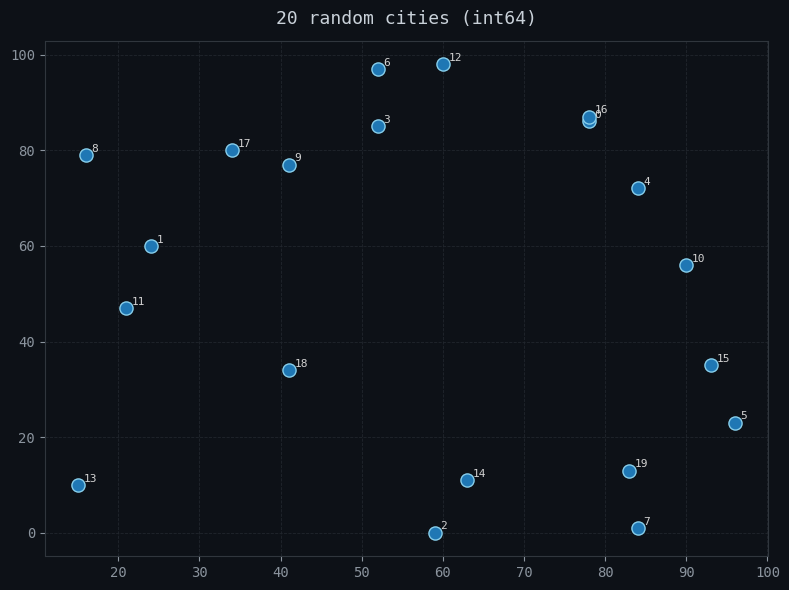

In [63]:
# –– Parameters –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
N_CITIES = 20
INIT_TEMP = 10_000
COOLING = 0.9975
MIN_TEMP = 0.01

# –– City positions (int but the solution is the same for float) ––––––––––––––––––––––
cities = np.random.randint(0, 101, size=(N_CITIES, 2))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cities[:, 0], cities[:, 1], s=90, edgecolors='skyblue', zorder=3)
for i, (x, y) in enumerate(cities):
    ax.text(x + 0.7, y + 0.7, str(i), fontsize=8, color='lightgrey', zorder=4)
ax.set_title(f"{N_CITIES} random cities ({type(x).__name__})", fontsize=13, pad=12)
ax.grid(True, ls='--')
plt.tight_layout()
plt.show()
# –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

## Pseudo code of Simulated Annealing Algorithm:

We will use simulated annealing which is an algorithm that mimic the annealing process in metallurgy.
The algorithm is as follow:
1. **Initialization:** Start with a random solution $s$ and a high temperature $T$.
2. **Neighbor Selection:** Pick a random nearby solution $s'$.
3. **Acceptance Criterion (Metropolis-Hastings):**
    - If $s'$ is better than s (lower cost), we accept the new solution ($s'=s$).
    - If $s'$ is worse, accept it with a probability $P=e^{-\frac{\Delta E}{T}}$.  
    Where $\Delta E$ is the increase in cost, $T$ is the current temperature.
4. **Cooling:** Gradually decrease T by a "cooling schedule"
5. **Iteration:** Repeat step 2-4 until the stopping condition is met.

## About the details of the algorithm:
- There are many way to select a neighbor of a solution, most often used is 2-opt swapping method which involve unrolling a self-intersecting loop. It has been proven that an optimal solution cannot have any self-intersection so the final solution must be a close, non-entangled loop.
- The Acceptance Criterion we use is Metropolis-Hastings. This criterion allows exploring less possible route with a decreasing probability. When $T$ is high, we prioritize breadth exploration. When $T$ is low, we prioritize depth exploration. More details will be discussed in the report.
- On the cooling schedule, we can have the temperature be a function which depends on the current state of our solution. The benefit of this approach is $T$ will decrease faster at the beginning after we had explored a wide range of solution. Later on, $T$ will decrease slowly to avoid getting stuck in a local solution.
- The stopping condition is worth mentionned. We can have a static condtion where the algorithm stops after $T$ hits a threshold. We can add a condtion if there's no remarkable improvement after some iterations.
- The circuit will have the structure: $[a_0, a_1, ..., a_{n-1}, a_0]$ where $a_i \in \{0, 1, ..., n-1\}$ to simplify and generalize the implementation.

In [64]:
# –– Two-opt swapping function ––––––––––––––––––––––––––––––––––––––––––––––––––––––––
def two_opt_swap(route, a, b):
    """
    2-opt swapping function.
    Given a route and 2 indices assumed a <= b, we do 2-opt swap by creating a new route
    which contain:
        start to route[a]
        route[a+1] to route[b] in reversed order
        route[b+1] to end
    Ex: Intial route: A->B->E->D->C->F->G->H
    two_opt_swap(route, 1, 4) give us:
        A->B  +  C->D->E  +  F->G->H
      = A->B  -> C->D->E  -> F->G->H
    """
    pos1, pos2 = min(a, b), max(a, b)
    return route[:pos1+1] + route[pos1+1:pos2+1][::-1] + route[pos2+1:]
# –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

In [65]:
# –– Boltzmann Probability calculation ––––––––––––––––––––––––––––––––––––––––––––––––
def proba_boltzmann(deltaE, T):
    """
    We perform the calculation of boltzmann probability:
        P = exp(-∆E/T) if ∆E >= 0 
        P = 1          if ∆E < 0
    for the Monte Carlo simulation of the acceptance.
    note P = 1 if ∆E < 0 because we choose the new solution when
        ∆E = new_cost - old_cost < 0
    i.e. the new solution is better.
    """
    return 1.0 if deltaE < 0 else math.exp(-deltaE/T)
# –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

In [66]:
# –– Function to calculate the length of a route ––––––––––––––––––––––––––––––––––––
def calc_dist(coords, r):
    """
    Calculate the total length of the route from a list of coordinants
    and the order of the route.
    """
    route_idx = np.array(r)
    reordered = coords[route_idx]

    diffs = np.diff(reordered, axis=0)
    return np.sqrt((diffs**2).sum(axis=1)).sum()
# –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

In [67]:
# –– Function to draw the route –––––––––––––––––––––––––––––––––––––––––––––––––––––
def draw_route(coords, r, size=(8, 6)):
    """
    Draw a route through every point from a list of coordinants
    and the order of the route.
    """
    fig, ax = plt.subplots(figsize=size)

    route_idx = np.array(r)
    reordered = coords[route_idx]

    ax.plot(reordered[:,0], reordered[:,1], '-', lw=1, ms=5, color='lightblue')
    ax.scatter(cities[:, 0], cities[:, 1], s=90, edgecolors='skyblue', zorder=3)

    for i, (x, y) in enumerate(coords):
        ax.text(x + 0.7, y + 0.7, str(i), fontsize=8, color='lightgrey', zorder=4)

    ax.set_title(f"TSP Circuit(Total Distance: {calc_dist(coords, r):.2f})")
    ax.grid(True, ls='--')
    plt.tight_layout()
    plt.show()
# –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

In [68]:
# –– Simulated Annealing Function –––––––––––––––––––––––––––––––––––––––––––––––––––––
def simulated_annealing(coords, init_temp, cooling_rate, min_temp):
    n = len(coords)
    circuit = list(range(n)) + [0]
    cost = calc_dist(coords, circuit)
    temp = init_temp

    draw_route(cities, circuit)

    while temp > min_temp:
        neighbor = two_opt_swap(circuit, rd.randint(0, n-1), rd.randint(0, n-1))
        neighbor_cost = calc_dist(coords, neighbor)
        delta = neighbor_cost - cost

        if neighbor_cost < cost or rd.random() < proba_boltzmann(delta, temp):
            circuit = neighbor
            cost = neighbor_cost

        temp *= cooling_rate
    
    draw_route(coords, circuit)
# –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

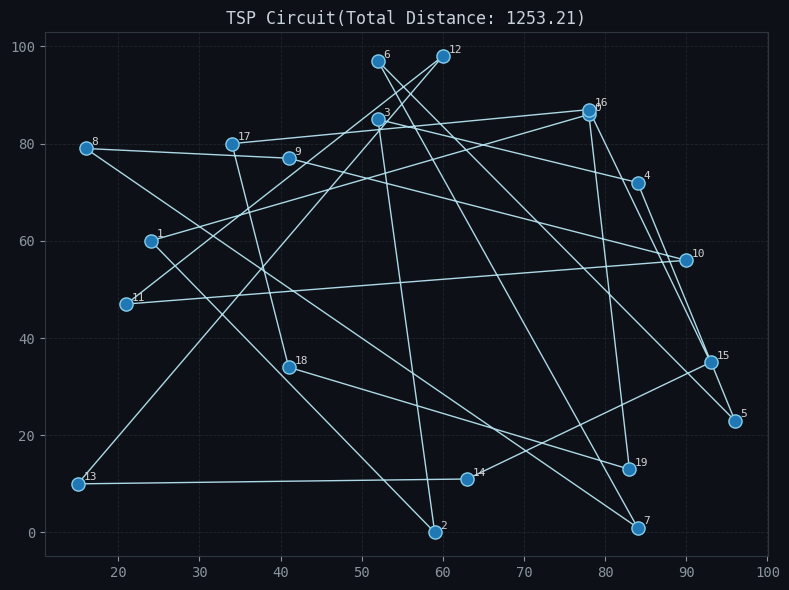

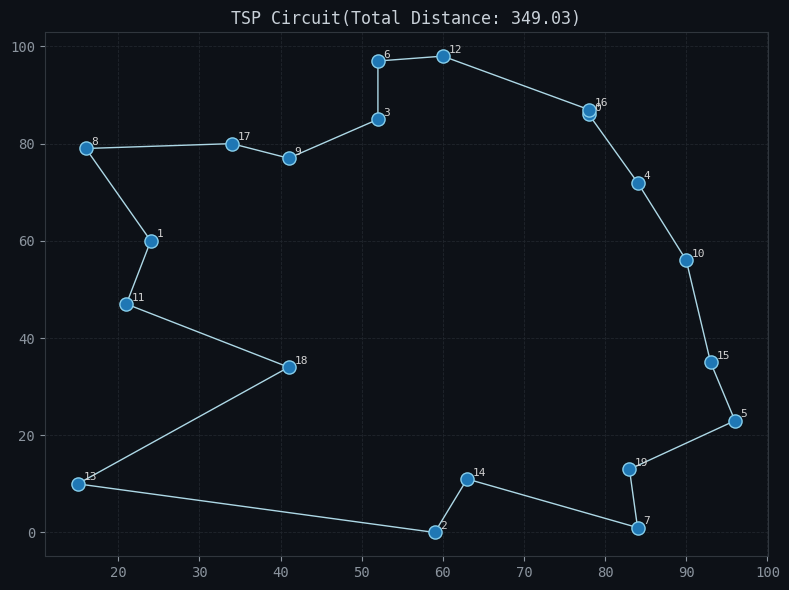

In [69]:
simulated_annealing(cities, INIT_TEMP, COOLING, MIN_TEMP)